In [ ]:
import glob
import torch
import numpy as np
import scipy as sp
import scipy.io
import scipy.signal
import time
import pandas as pd
import math
from utils.data_utils import *
from utils.viz_utils import *
from model.motionPPGNet import motionPPGNet

from torch import nn
import torch.optim as optim
from scipy.io import loadmat
import matplotlib.pyplot as plt
from matplotlib import figure
from scipy.signal import savgol_filter
from scipy.signal import butter, lfilter
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
torch.manual_seed(42)
np.random.seed(42)

fs = 125
minBPM = 40
maxBPM = 240
window_length = 8 * fs
window_shift = 2 * fs  #Overlap = window_length - window_shift
batch_size = 25
verbose, epochs = 1, 100

# Retrieve dataset files
data_dir = "datasets/troika/training_data"
data_fls, ref_fls = LoadTroikaDataset(data_dir)
errs, confs = [], []

device = (
    "cuda"
    if torch.cuda.is_available()
    # else "mps"  # Disabled MPS as I was getting unusual training issues
    # if torch.backends.mps.is_available()
    else "cpu"
)
# device = "cpu"
print(f"Using {device} device")

Using cpu device


In [ ]:
def create_overlap_aware_split(dataset, window_shift, window_length, train_ratio=0.8):
    """
    Create train/test split that accounts for window overlap.
    
    Args:
        dataset: Your TroikaDataset instance
        window_shift: Shift between consecutive windows (in samples)
        window_length: Length of each window (in samples)
        train_ratio: Desired proportion for training
    
    Returns:
        (train_loader, test_loader)
    """
    total_windows = len(dataset)
    
    # Calculate how many windows of overlap we have
    overlap_samples = window_length - window_shift
    overlap_windows = math.ceil(overlap_samples / window_shift)
    
    train_end = int(total_windows * train_ratio)
    
    # Create gap to prevent overlap
    test_start = train_end + overlap_windows
    
    if test_start >= total_windows:
        raise ValueError(f"Not enough data for split. Need at least {test_start} windows, but only have {total_windows}")
    
    train_indices = list(range(0, train_end))
    test_indices = list(range(test_start, total_windows))
    
    print(f"Window overlap: {overlap_samples} samples ({overlap_windows} windows)")
    print(f"Train windows: 0 to {train_end-1} ({len(train_indices)} windows)")
    print(f"Gap: {overlap_windows} windows")
    print(f"Test windows: {test_start} to {total_windows-1} ({len(test_indices)} windows)")
    
    # Create samplers
    train_sampler = torch.utils.data.SubsetRandomSampler(train_indices)
    test_sampler = torch.utils.data.SubsetRandomSampler(test_indices)
    
    # Create data loaders
    train_loader = DataLoader(dataset, batch_size=batch_size, sampler=train_sampler)
    test_loader = DataLoader(dataset, batch_size=batch_size, sampler=test_sampler)
    
    return train_loader, test_loader

# Create the dataset
dataset = TroikaDataset(data_fls, ref_fls, window_length, window_shift, fs)

# Split the dataset into training and testing
train_size = 0.8
num_train = int(len(dataset) * train_size)
num_test = len(dataset) - num_train
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [num_train, num_test])
train_loader, test_loader = create_overlap_aware_split(dataset, window_shift, window_length, train_ratio=0.8)

for i in range(0, len(dataset), 400):
    visualize_dataset_sample(dataset, i)
    

Window overlap: 750 samples (3 windows)
Train windows: 0 to 1379 (1380 windows)
Gap: 3 windows
Test windows: 1383 to 1725 (343 windows)


In [12]:
ppg, acc, targets = dataset[0]
print(ppg.shape)
print(acc.shape)
print(targets.shape)
print(targets)
for ppg, acc, targets in train_loader:
    print(ppg.shape)
    print(acc.shape)
    print(targets.shape)
    print(targets)
    break

torch.Size([1, 1000])
torch.Size([1, 1000])
torch.Size([])
tensor(74.3392)
torch.Size([25, 1, 1000])
torch.Size([25, 1, 1000])
torch.Size([25])
tensor([153.8877, 143.9232,  89.7715, 144.5396, 116.5803, 153.8877, 142.7061,
        133.3333, 129.0486, 103.8339, 123.0853, 142.8571, 150.3165, 126.5823,
         90.1640, 142.5554, 160.4278, 168.3673, 109.4891, 159.0668, 136.3636,
        166.3147, 143.7700, 110.9937, 126.1830])


In [ ]:
import torch
import torch.nn as nn
import math

class HeartRateTransformer(nn.Module):
    def __init__(self, heartgpt_ppg_path, device='cuda'):
        super().__init__()
        self.device = device
        self.max_len = 500
        self.d_model = 64
        
        # Load HeartGPT embeddings
        self.load_heartgpt_embeddings(heartgpt_ppg_path)
        
        # Modern transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=64, nhead=8, dim_feedforward=256, dropout=0.1, 
            activation='gelu', batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=8)
        
        # Output layers
        self.act = nn.GELU()
        self.dropout1 = nn.Dropout(0.1)
        self.output_layer = nn.Linear(64 * 500, 1)
        
        self.to(device)
    
    def load_heartgpt_embeddings(self, path):
        """Load HeartGPT embeddings"""
        try:
            ppg_pt_state = torch.load(path, map_location=self.device)
            
            # Token embeddings
            self.heartgpt_token_embedding = nn.Embedding(101, 64)
            if 'token_embedding_table.weight' in ppg_pt_state:
                self.heartgpt_token_embedding.weight.data = ppg_pt_state['token_embedding_table.weight']
            
            # Positional embeddings
            if 'position_embedding_table.weight' in ppg_pt_state:
                self.heartgpt_pos_embedding = nn.Parameter(ppg_pt_state['position_embedding_table.weight'].clone())
            else:
                self.heartgpt_pos_embedding = nn.Parameter(torch.zeros(500, 64))
                
        except:
            print("Could not load HeartGPT embeddings, creating new ones")
            self.heartgpt_token_embedding = nn.Embedding(101, 64)
            self.heartgpt_pos_embedding = nn.Parameter(torch.zeros(500, 64))
  
    def preprocess_batch(self, ppg_batch):
        """Convert raw PPG to HeartGPT tokens"""
        ppg_signals = ppg_batch.squeeze(1)  # [batch, 1000]
        downsampled = ppg_signals[:, ::2]   # [batch, 500]
        
        # HeartGPT tokenization
        batch_min = downsampled.min(dim=1, keepdim=True)[0]
        batch_max = downsampled.max(dim=1, keepdim=True)[0]
        normalized = (downsampled - batch_min) / (batch_max - batch_min + 1e-8)
        tokens = torch.round(normalized * 100).long()
        tokens = torch.clamp(tokens, 0, 100)
        
        return tokens
    
    def forward(self, ppg_batch, padding_masks=None):
        """Forward pass"""
        batch_size = ppg_batch.shape[0]
        
        if padding_masks is None:
            padding_masks = torch.ones(batch_size, 500, dtype=torch.bool, device=self.device)
        
        # Get HeartGPT tokens and embeddings
        tokens = self.preprocess_batch(ppg_batch)
        tok_emb = self.heartgpt_token_embedding(tokens)
        pos_emb = self.heartgpt_pos_embedding[:500]
        x = tok_emb + pos_emb.unsqueeze(0)
        x = x * math.sqrt(self.d_model)
        
        # Transformer
        output = self.transformer_encoder(x, src_key_padding_mask=~padding_masks)
        output = self.act(output)
        output = self.dropout1(output)
        
        # Final prediction
        output = output * padding_masks.unsqueeze(-1)
        output = output.reshape(batch_size, -1)
        output = self.output_layer(output)
        
        return output


# Example usage
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = HeartRateTransformer(heartgpt_ppg_path="PPGPT_beat_5k_iters.pth", device=device)

# Test
dummy_ppg = torch.randn(2, 1, 1000).to(device)
output = model(dummy_ppg)
print(f"Output shape: {output.shape}")

# Training loop example (like your original)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
criterion = nn.MSELoss()

for epoch in range(1, 101):  # 100 epochs
    model.train()
    epoch_train_loss = 0
    train_batches = 0
    
    # Replace with your actual train_loader
    for ppg, acc, targets in train_loader:
        inputs, targets = ppg.to(device), targets.to(device)
        
        optimizer.zero_grad()
        hr_pred = model(inputs)
        loss = criterion(hr_pred.squeeze(), targets)
        loss.backward()
        optimizer.step()
        
        epoch_train_loss += loss.item()
        train_batches += 1
    
    avg_train_loss = epoch_train_loss / train_batches
    
    # Validation every 10 epochs
    if epoch % 10 == 0:
        model.eval()
        val_loss = 0
        val_batches = 0
        
        with torch.no_grad():
            for ppg, _, targets in test_loader:
                inputs, targets = ppg.to(device), targets.to(device)
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, targets)
                val_loss += loss.item()
                val_batches += 1
                
        print(f'Epoch {epoch}: Train Loss: {avg_train_loss:.2f}, Val Loss: {val_loss/val_batches:.2f}')

# import time
# all_time = 0
# optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
# criterion = nn.MSELoss()

# for epoch in range(1, epochs+1):
#     model.train()
#     epoch_train_loss = 0
#     train_batches = 0
    
#     for ppg, acc, targets in train_loader:
#         inputs, targets = ppg.to(device), targets.to(device)
#         # inputs shape: [25, 1, 1000]
        
#         optimizer.zero_grad()
        
#         old = time.time()
#         # No need for padding_masks with your data - all sequences are same length
#         hr_pred = model(inputs)  # Clean and simple!
#         all_time += time.time() - old
        
#         loss = criterion(hr_pred.squeeze(), targets)
#         loss.backward()
#         optimizer.step()
        
#         epoch_train_loss += loss.item()
#         train_batches += 1
    
#     avg_train_loss = epoch_train_loss / train_batches
    
#     # Validation
#     if epoch % 10 == 0:
#         model.eval()
#         val_abs_error = 0
#         val_samples = 0
        
#         with torch.no_grad():
#             total_loss = 0
#             for ppg, _, targets in test_loader:
#                 inputs, targets = ppg.to(device), targets.to(device)
#                 outputs = model(inputs).squeeze()
                
#                 loss = criterion(outputs, targets)
#                 abs_error = torch.abs(outputs - targets).sum().item()
#                 val_abs_error += abs_error
#                 val_samples += targets.size(0)
#                 total_loss += loss.item()
                
#             print(f'Epoch {epoch}:')
#             print(f"Training Loss: {avg_train_loss:.2f}")
#             print(f"Test&Val Loss: {total_loss / len(test_loader):.2f}")
#             print(f"Val MAE: {val_abs_error / val_samples:.2f}")

# print(f"Time for {epochs} epochs: {all_time:.2f}s")

Loading HeartGPT embeddings from: PPGPT_beat_5k_iters.pth
Pretrained embedding shape: torch.Size([102, 64])
Loaded token embeddings: torch.Size([102, 64])
Loaded positional embeddings: torch.Size([500, 64])
HeartGPT embeddings loaded successfully!
Token embedding shape: torch.Size([102, 64])
Position embedding shape: torch.Size([500, 64])


TypeError: forward() got an unexpected keyword argument 'is_causal'

In [ ]:
import torch
import torch.nn as nn
import math
from typing import Optional


class HeartRateTransformer(nn.Module):
    def __init__(self, heartgpt_ppg_path: str, device: str = 'cuda'):
        super().__init__()
        self.device = device
        self.max_len = 500
        self.d_model = 64
        self.n_heads = 8
        self.num_layers = 8
        self.dropout = 0.1
        
        # Load HeartGPT embeddings
        self.load_heartgpt_embeddings(heartgpt_ppg_path)
        
        # Modern transformer encoder using PyTorch's built-in implementation
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.d_model,
            nhead=self.n_heads,
            dim_feedforward=256,
            dropout=self.dropout,
            activation='gelu',
            batch_first=True,  # Use batch_first=True for modern PyTorch
            norm_first=True    # Pre-norm architecture (more stable)
        )
        
        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer, 
            num_layers=self.num_layers
        )
        
        # Output layers
        self.layer_norm = nn.LayerNorm(self.d_model)
        self.dropout_final = nn.Dropout(self.dropout)
        self.output_layer = nn.Linear(self.d_model * self.max_len, 1)
        
        self.to(device)
    
    def load_heartgpt_embeddings(self, path: str):
        """Load both token AND positional embeddings from HeartGPT"""
        print(f"Loading HeartGPT embeddings from: {path}")
        try:
            ppg_pt_state = torch.load(path, map_location=self.device)
            
            # Load token embeddings (0-100 → 64-dim)
            if 'token_embedding_table.weight' in ppg_pt_state:
                token_weights = ppg_pt_state['token_embedding_table.weight']
                vocab_size = token_weights.shape[0]
                
                self.heartgpt_token_embedding = nn.Embedding(vocab_size, self.d_model)
                self.heartgpt_token_embedding.weight.data = token_weights
                print(f"Loaded token embeddings: {self.heartgpt_token_embedding.weight.shape}")
            else:
                # Fallback: create new token embedding
                print("Token embeddings not found, creating new ones")
                self.heartgpt_token_embedding = nn.Embedding(101, self.d_model)
                nn.init.normal_(self.heartgpt_token_embedding.weight, std=0.02)
            
            # Load positional embeddings (0-499 → 64-dim)
            if 'position_embedding_table.weight' in ppg_pt_state:
                pos_weights = ppg_pt_state['position_embedding_table.weight']
                self.heartgpt_pos_embedding = nn.Parameter(pos_weights.clone())
                print(f"Loaded positional embeddings: {self.heartgpt_pos_embedding.shape}")
                
                # Verify dimensions
                assert self.heartgpt_pos_embedding.shape[0] >= self.max_len, \
                    f"Position embedding length {self.heartgpt_pos_embedding.shape[0]} < max_len {self.max_len}"
                assert self.heartgpt_pos_embedding.shape[1] == self.d_model, \
                    f"Position embedding dim {self.heartgpt_pos_embedding.shape[1]} != d_model {self.d_model}"
            else:
                # Fallback: create new positional embedding
                print("Positional embeddings not found, creating new ones")
                self.heartgpt_pos_embedding = nn.Parameter(
                    torch.zeros(self.max_len, self.d_model)
                )
                nn.init.normal_(self.heartgpt_pos_embedding, std=0.02)
                
        except Exception as e:
            print(f"Error loading HeartGPT embeddings: {e}")
            print("Creating new embeddings...")
            # Create fallback embeddings
            self.heartgpt_token_embedding = nn.Embedding(101, self.d_model)
            self.heartgpt_pos_embedding = nn.Parameter(
                torch.zeros(self.max_len, self.d_model)
            )
            nn.init.normal_(self.heartgpt_token_embedding.weight, std=0.02)
            nn.init.normal_(self.heartgpt_pos_embedding, std=0.02)
    
    def preprocess_batch(self, ppg_batch: torch.Tensor) -> torch.Tensor:
        """Convert raw PPG to HeartGPT tokens"""
        # Handle different input shapes
        if ppg_batch.dim() == 3 and ppg_batch.shape[1] == 1:
            ppg_signals = ppg_batch.squeeze(1)  # [batch, 1, length] -> [batch, length]
        elif ppg_batch.dim() == 2:
            ppg_signals = ppg_batch  # [batch, length]
        else:
            raise ValueError(f"Unexpected input shape: {ppg_batch.shape}")
        
        # Downsample if needed (assuming input is 1000 samples, output should be 500)
        if ppg_signals.shape[1] > self.max_len:
            step = ppg_signals.shape[1] // self.max_len
            downsampled = ppg_signals[:, ::step][:, :self.max_len]
        else:
            downsampled = ppg_signals[:, :self.max_len]
        
        # HeartGPT tokenization (normalize to 0-100 range)
        batch_min = downsampled.min(dim=1, keepdim=True)[0]
        batch_max = downsampled.max(dim=1, keepdim=True)[0]
        
        # Avoid division by zero
        range_vals = batch_max - batch_min
        range_vals = torch.where(range_vals > 1e-8, range_vals, torch.ones_like(range_vals))
        
        normalized = (downsampled - batch_min) / range_vals
        tokens = torch.round(normalized * 100).long()
        tokens = torch.clamp(tokens, 0, 100)
        
        return tokens
    
    def forward(self, ppg_batch: torch.Tensor, padding_masks: Optional[torch.Tensor] = None) -> torch.Tensor:
        """Forward pass with HeartGPT embeddings and modern transformer"""
        batch_size = ppg_batch.shape[0]
        
        # Create default padding mask if not provided
        if padding_masks is None:
            padding_masks = torch.ones(batch_size, self.max_len, dtype=torch.bool, device=self.device)
        
        # Get HeartGPT tokens
        tokens = self.preprocess_batch(ppg_batch)  # [batch, max_len]
        
        # Apply HeartGPT token embeddings
        tok_emb = self.heartgpt_token_embedding(tokens)  # [batch, max_len, d_model]
        
        # Apply HeartGPT positional embeddings
        pos_indices = torch.arange(self.max_len, device=self.device)
        pos_emb = self.heartgpt_pos_embedding[pos_indices]  # [max_len, d_model]
        
        # Combine embeddings (HeartGPT style)
        x = tok_emb + pos_emb.unsqueeze(0)  # [batch, max_len, d_model]
        
        # Scale embeddings (as in original transformer)
        x = x * math.sqrt(self.d_model)
        
        # Create attention mask for transformer (inverted padding mask)
        # PyTorch transformer expects True for positions to IGNORE
        src_key_padding_mask = ~padding_masks
        
        # Pass through transformer encoder
        # Modern PyTorch transformers expect [batch, seq, features] when batch_first=True
        output = self.transformer_encoder(
            x, 
            src_key_padding_mask=src_key_padding_mask
        )  # [batch, max_len, d_model]
        
        # Apply layer norm and dropout
        output = self.layer_norm(output)
        output = self.dropout_final(output)
        
        # Apply padding mask to zero out padded positions
        output = output * padding_masks.unsqueeze(-1).float()
        
        # Flatten and predict
        output = output.reshape(batch_size, -1)  # [batch, max_len * d_model]
        output = self.output_layer(output)  # [batch, 1]
        
        return output


# Example usage and testing
if __name__ == "__main__":
    # Set device
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Using device: {device}")
    
    # Initialize model
    try:
        model = HeartRateTransformer(
            heartgpt_ppg_path="PPGPT_beat_5k_iters.pth", 
            device=device
        )
        print("Model initialized successfully!")
    except Exception as e:
        print(f"Error initializing model: {e}")
        # You can still create the model without pretrained weights
        model = HeartRateTransformer(
            heartgpt_ppg_path="dummy_path.pth",  # Will use fallback embeddings
            device=device
        )
    
    # Test with dummy data
    batch_size = 4
    sequence_length = 1000
    
    # Create dummy PPG data
    dummy_ppg = torch.randn(batch_size, 1, sequence_length).to(device)
    
    # Forward pass
    with torch.no_grad():
        output = model(dummy_ppg)
        print(f"Input shape: {dummy_ppg.shape}")
        print(f"Output shape: {output.shape}")
        print(f"Output values: {output.squeeze()}")
    
    # Print model info
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nTotal parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")


# Training setup example
def setup_training(model, train_loader, device, lr=3e-4, epochs=100):
    """Setup training components"""
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    criterion = nn.MSELoss()
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    return optimizer, criterion, scheduler


def train_epoch(model, train_loader, optimizer, criterion, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    num_batches = 0
    
    for batch_idx, (ppg, targets) in enumerate(train_loader):
        ppg, targets = ppg.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(ppg)
        loss = criterion(outputs.squeeze(), targets)
        loss.backward()
        
        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        total_loss += loss.item()
        num_batches += 1
    
    return total_loss / num_batches


def validate(model, val_loader, criterion, device):
    """Validate the model"""
    model.eval()
    total_loss = 0
    num_batches = 0
    
    with torch.no_grad():
        for ppg, targets in val_loader:
            ppg, targets = ppg.to(device), targets.to(device)
            outputs = model(ppg)
            loss = criterion(outputs.squeeze(), targets)
            total_loss += loss.item()
            num_batches += 1
    
    return total_loss / num_batches

# Initialize model
model = HeartRateTransformer(
    heartgpt_ppg_path="PPGPT_beat_5k_iters.pth",
    device='cpu'
)

# Your existing training loop should work with minimal changes
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
criterion = nn.MSELoss()

for epoch in range(epochs):
    for ppg_batch,_, targets in train_loader:
        ppg_batch, targets = ppg_batch.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(ppg_batch)
        loss = criterion(outputs.squeeze(), targets)
        loss.backward()
        optimizer.step()

Output shape: torch.Size([2, 1])


KeyboardInterrupt: 

In [21]:
n_timesteps, n_features, n_outputs = len(train_dataset[0][0][0]), 1, 1
learning_rate = 1e-3
# epochs = 5

# Initialize the model
model = motionPPGNet(n_timesteps, n_features, n_outputs)
model.to(device)

# Loss and optimizer
criterion = nn.MSELoss()
learning_rate = 1e-3  # Reduce by 10x
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
# optimizer = optim.Adam(model.parameters(), lr=0.001)
# optimizer = optim.RMSprop(model.parameters(), lr=learning_rate)

print(n_timesteps)

Sequence length after convolutions: 50
1000


In [ ]:
# Training loop
# for epoch in range(epochs):
#     model.train()
#     for ppg, acc, targets in train_loader:
#         inputs, targets = ppg.to(device), targets.to(device)
#         optimizer.zero_grad()
#         outputs = model(inputs)
#         loss = criterion(outputs, targets)
#         loss.backward()
#         optimizer.step()

#     if epoch % 10 == 0:  # Validation every 10 epochs
#         model.eval()
#         with torch.no_grad():
#             total_loss = 0
#             for ppg, acc, targets in test_loader:
#                 inputs, targets = ppg.to(device), targets.to(device)
#                 outputs = model(inputs)
#                 loss = criterion(outputs, targets)
#                 total_loss += loss.item()
#             print(f'Epoch {epoch}: Validation Loss: {total_loss / len(test_loader)}')

# In TF Code had about 2 MSE




KeyboardInterrupt: 

In [ ]:
"""Print a simple text representation of PyTorch model structure"""
print("=" * 60)
print("PYTORCH MODEL STRUCTURE")
print("=" * 60)
print(model)

# Print parameter count
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")
print("=" * 60)

PYTORCH MODEL STRUCTURE
motionPPGNet(
  (conv1): Conv1d(1, 32, kernel_size=(40,), stride=(1,))
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.1, inplace=False)
  (conv2): Conv1d(32, 32, kernel_size=(40,), stride=(1,))
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  (dropout2): Dropout(p=0.1, inplace=False)
  (lstm1): LSTM(32, 128, batch_first=True)
  (lstm2): LSTM(128, 128, batch_first=True)
  (dense): Linear(in_features=128, out_features=1, bias=True)
)

Total trainable parameters: 257,601


In [ ]:
import torch.nn.functional as F
def print_pytorch_shapes(model, input_shape=(1, 1, 1000)):  # (batch, channel, sequence_length)
    """Print output shapes for each layer in the PyTorch model"""
    device = next(model.parameters()).device
    x = torch.randn(input_shape).to(device)
    
    # Original input
    print(f"Input: {x.shape}")
    
    # Conv1 block
    # No need for initial permute - data is already in (batch, channel, sequence)
    
    x = model.conv1(x)
    print(f"After conv1: {x.shape}")
    
    x = model.bn1(x)
    print(f"After bn1: {x.shape}")
    
    x = F.relu(x)
    print(f"After relu1: {x.shape}")
    
    x = model.pool1(x)
    print(f"After pool1: {x.shape}")
    
    x = model.dropout1(x)
    print(f"After dropout1: {x.shape}")
    
    # Conv2 block
    x = model.conv2(x)
    print(f"After conv2: {x.shape}")
    
    x = model.bn2(x)
    print(f"After bn2: {x.shape}")
    
    x = F.relu(x)
    print(f"After relu2: {x.shape}")
    
    x = model.pool2(x)
    print(f"After pool2: {x.shape}")
    
    x = model.dropout2(x)
    print(f"After dropout2: {x.shape}")
    
    # LSTM layers
    # Need permute here to change from (batch, channel, sequence) to (batch, sequence, channel)
    x = x.permute(0, 2, 1)
    print(f"After permute for LSTM: {x.shape}")
    
    x, _ = model.lstm1(x)
    print(f"After lstm1: {x.shape}")
    
    _, (h_n, _) = model.lstm2(x)

    x = h_n.squeeze(0)  # Getting the last hidden state
    print(f"Last hidden state: {x.shape}")
    
    # Final layer
    x = model.dense(x).squeeze()  # Note: in your model it's called 'dense', not 'fc'
    print(f"Output: {x.shape}")

# Usage:
print_pytorch_shapes(model, input_shape=(25, 1, window_length))  # For single channel (PPG only)

Input: torch.Size([25, 1, 1000])
After conv1: torch.Size([25, 32, 961])
After bn1: torch.Size([25, 32, 961])
After relu1: torch.Size([25, 32, 961])
After pool1: torch.Size([25, 32, 240])
After dropout1: torch.Size([25, 32, 240])
After conv2: torch.Size([25, 32, 201])
After bn2: torch.Size([25, 32, 201])
After relu2: torch.Size([25, 32, 201])
After pool2: torch.Size([25, 32, 50])
After dropout2: torch.Size([25, 32, 50])
After permute for LSTM: torch.Size([25, 50, 32])
After lstm1: torch.Size([25, 50, 128])
Last hidden state: torch.Size([25, 128])
Output: torch.Size([25])


In [ ]:
## Qualitative Evals

# Load all data
X = []
y = np.array([])

print(data_fls)

data_fl = data_fls[-1]
ref_fl = ref_fls[-1]
# load data using LoadTroikaDataFile
ppg, accx, accy, accz = LoadTroikaDataFile(data_fl)

# bandpass filter the signals
ppg = bandpass_filter(ppg, fs)
accx = bandpass_filter(accx, fs)
accy = bandpass_filter(accy, fs)
accz = bandpass_filter(accz, fs)

# Consider only magnitude of acceleration
acc = calculate_magnitude(accx, accy, accz)

# Standardization
ppg = (ppg- np.mean(ppg))/np.std(ppg)
acc = (acc- np.mean(acc))/np.std(acc)

# loading the reference file
ground_truth = sp.io.loadmat(ref_fl)['BPM0'].reshape(-1)
y = np.array(ground_truth)

for i in range(0, len(ppg) - window_length + 1, window_shift):

    # aggregate accelerometer data into single signal to get the acc window
    ppg_window = ppg[i:i+window_length]
    acc_window = acc[i:i+window_length]

    X.append(ppg_window)

X = np.array(X)
print(X.shape)
print(y.shape)

with torch.no_grad():
    pred = model(X)



['datasets/troika/training_data/DATA_01_TYPE01.mat', 'datasets/troika/training_data/DATA_02_TYPE02.mat', 'datasets/troika/training_data/DATA_03_TYPE02.mat', 'datasets/troika/training_data/DATA_04_TYPE01.mat', 'datasets/troika/training_data/DATA_04_TYPE02.mat', 'datasets/troika/training_data/DATA_05_TYPE02.mat', 'datasets/troika/training_data/DATA_06_TYPE02.mat', 'datasets/troika/training_data/DATA_07_TYPE02.mat', 'datasets/troika/training_data/DATA_08_TYPE02.mat', 'datasets/troika/training_data/DATA_10_TYPE02.mat', 'datasets/troika/training_data/DATA_11_TYPE02.mat', 'datasets/troika/training_data/DATA_12_TYPE02.mat']
(146, 1000)
(146,)


Evaluating on: datasets/troika/training_data/DATA_12_TYPE02.mat
PPG windows shape: (146, 1000)
Ground truth shape: (146,)

Metrics:
MAE: 5.37 BPM
RMSE: 8.31 BPM
Correlation: 0.938


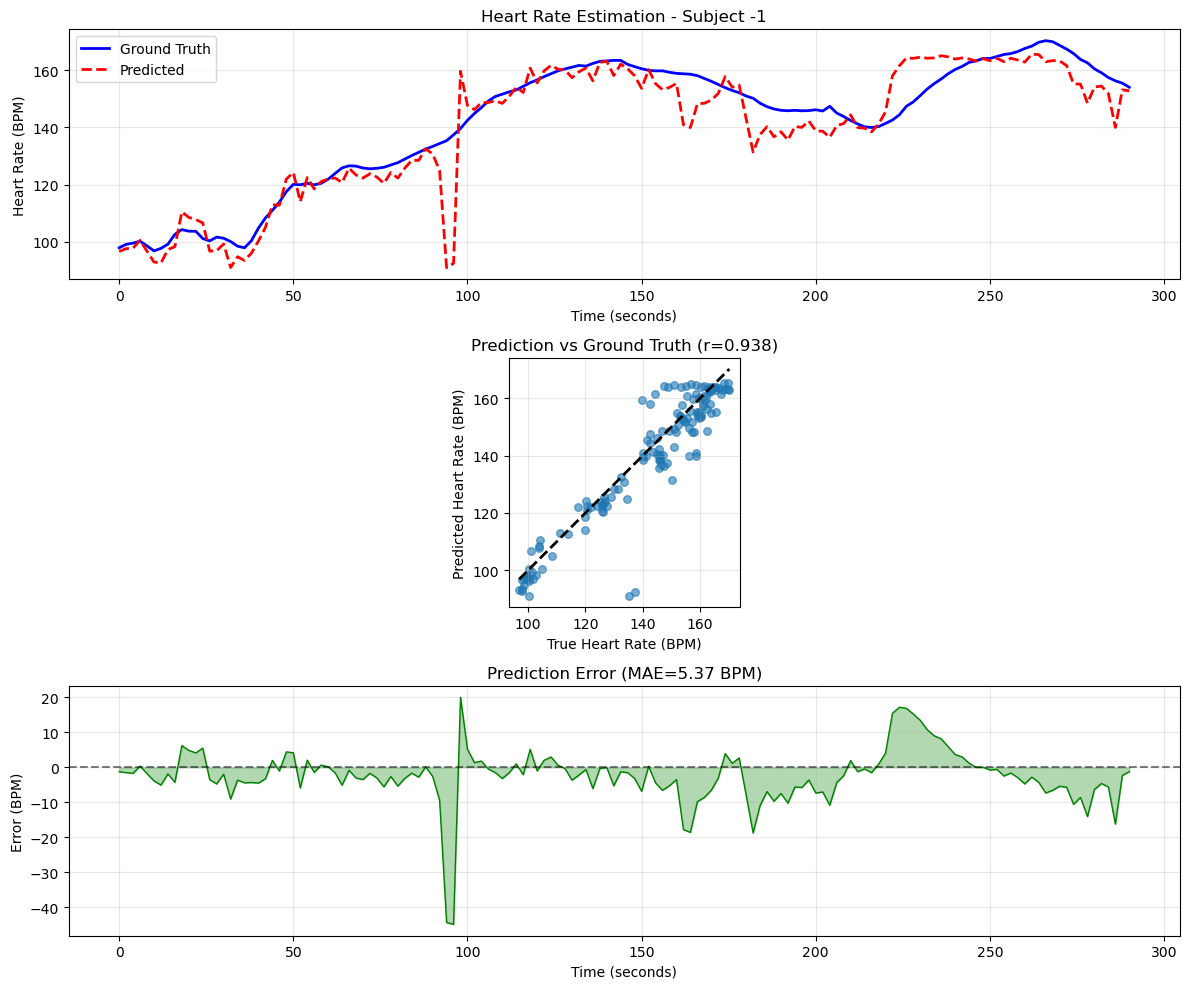

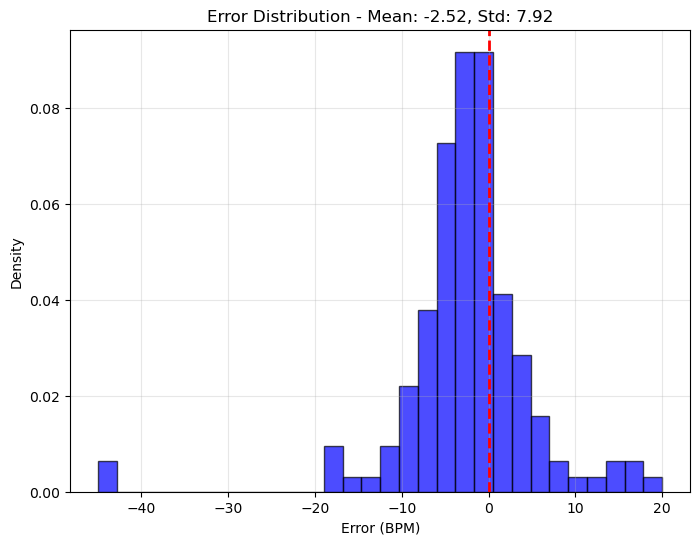


Activity-wise MAE:
Rest (1-2 km/h): 3.38 BPM
Walk (6-8 km/h): 3.12 BPM
Run (12-15 km/h): 5.87 BPM
Walk (6-8 km/h): 7.29 BPM
Run (12-15 km/h): 5.47 BPM


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

## Qualitative Evaluation for New Subject

# Select a subject (e.g., the last one)
subject_idx = -1  # You can change this to any subject index
data_fl = data_fls[subject_idx]
ref_fl = ref_fls[subject_idx]

print(f"Evaluating on: {data_fl}")

# Load data using LoadTroikaDataFile
ppg, accx, accy, accz = LoadTroikaDataFile(data_fl)

# Apply bandpass filter
ppg = bandpass_filter(ppg, fs)
accx = bandpass_filter(accx, fs)
accy = bandpass_filter(accy, fs)
accz = bandpass_filter(accz, fs)

# Calculate acceleration magnitude
acc = calculate_magnitude(accx, accy, accz)

# Normalize the signals (same as in dataset)
ppg = (ppg - np.mean(ppg)) / np.std(ppg)
acc = (acc - np.mean(acc)) / np.std(acc)

# Load ground truth BPM
ground_truth_all = loadmat(ref_fl)['BPM0'].reshape(-1)

# Create windows
X_ppg = []
X_acc = []
y_true = []

for i in range(0, len(ppg) - window_length + 1, window_shift):
    ppg_window = ppg[i:i + window_length]
    acc_window = acc[i:i + window_length]
    
    X_ppg.append(ppg_window)
    X_acc.append(acc_window)

# Convert to numpy arrays
X_ppg = np.array(X_ppg).astype('float32')
X_acc = np.array(X_acc).astype('float32')
y_true = np.array(ground_truth_all).astype('float32')

print(f"PPG windows shape: {X_ppg.shape}")
print(f"Ground truth shape: {y_true.shape}")

# Convert to PyTorch tensors with correct dimensions
# Model expects: (batch_size, channels=1, sequence_length)
X_ppg_tensor = torch.tensor(X_ppg).unsqueeze(1).to(device)

# Get predictions
model.eval()  # Set model to evaluation mode
with torch.no_grad():
    y_pred = model(X_ppg_tensor)
    y_pred = y_pred.cpu().numpy()  # Convert back to numpy

# Calculate metrics
mae = np.mean(np.abs(y_pred - y_true))
rmse = np.sqrt(np.mean((y_pred - y_true)**2))
correlation = np.corrcoef(y_pred, y_true)[0, 1]

print(f"\nMetrics:")
print(f"MAE: {mae:.2f} BPM")
print(f"RMSE: {rmse:.2f} BPM")
print(f"Correlation: {correlation:.3f}")

# Plotting
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Plot 1: Time series comparison
time_axis = np.arange(len(y_true)) * window_shift / fs  # Convert to seconds
axes[0].plot(time_axis, y_true, 'b-', label='Ground Truth', linewidth=2)
axes[0].plot(time_axis, y_pred, 'r--', label='Predicted', linewidth=2)
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('Heart Rate (BPM)')
axes[0].set_title(f'Heart Rate Estimation - Subject {subject_idx}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Scatter plot
axes[1].scatter(y_true, y_pred, alpha=0.6, s=30)
axes[1].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', lw=2)
axes[1].set_xlabel('True Heart Rate (BPM)')
axes[1].set_ylabel('Predicted Heart Rate (BPM)')
axes[1].set_title(f'Prediction vs Ground Truth (r={correlation:.3f})')
axes[1].grid(True, alpha=0.3)
axes[1].set_aspect('equal', adjustable='box')

# Plot 3: Error over time
error = y_pred - y_true
axes[2].plot(time_axis, error, 'g-', linewidth=1)
axes[2].axhline(y=0, color='k', linestyle='--', alpha=0.5)
axes[2].fill_between(time_axis, 0, error, alpha=0.3, color='green')
axes[2].set_xlabel('Time (seconds)')
axes[2].set_ylabel('Error (BPM)')
axes[2].set_title(f'Prediction Error (MAE={mae:.2f} BPM)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Additional analysis: Error distribution
plt.figure(figsize=(8, 6))
plt.hist(error, bins=30, density=True, alpha=0.7, color='blue', edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Error (BPM)')
plt.ylabel('Density')
plt.title(f'Error Distribution - Mean: {np.mean(error):.2f}, Std: {np.std(error):.2f}')
plt.grid(True, alpha=0.3)
plt.show()

# Activity-wise analysis (if using Type 1 activity data)
if subject_idx < 12:  # Type 1 subjects
    # Define activity segments based on the paper
    activities = [
        ("Rest (1-2 km/h)", 0, 30),
        ("Walk (6-8 km/h)", 30, 90),
        ("Run (12-15 km/h)", 90, 150),
        ("Walk (6-8 km/h)", 150, 210),
        ("Run (12-15 km/h)", 210, 270),
        ("Rest (1-2 km/h)", 270, 300)
    ]
    
    print("\nActivity-wise MAE:")
    for activity_name, start_s, end_s in activities:
        # Convert seconds to window indices
        start_idx = int(start_s * fs / window_shift)
        end_idx = int(end_s * fs / window_shift)
        
        if end_idx <= len(y_true):
            activity_mae = np.mean(np.abs(y_pred[start_idx:end_idx] - y_true[start_idx:end_idx]))
            print(f"{activity_name}: {activity_mae:.2f} BPM")

In [ ]:
# fit and evaluate a model (trainX, trainy, testX, testy):